## Anomaly Screening on FORTS Futures

Initial exploration of four return anomalies on MOEX FORTS (Si, RI, BR futures):

1. **Overnight gap fade** -- mean reversion of overnight gaps between evening close and morning open
2. **Intraday mean reversion** -- fading extreme hourly moves using z-score signals
3. **Day-of-week effect** -- testing for systematic calendar patterns
4. **Pre-expiration volatility** -- whether realized vol increases predictably before contract expiry

Data: hourly candles from MOEX ISS API (Jun 2024 -- May 2026).

In [1]:
# Imports and MOEX ISS data loader

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

MOEX_BASE = "https://iss.moex.com/iss"
import time

def moex_get_candles(security, interval=60, start="2024-01-01", end=None,
                     engine="futures", market="forts"):
    if end is None:
        end = datetime.now().strftime("%Y-%m-%d")
    all_rows, page_start = [], 0
    while True:
        url = f"{MOEX_BASE}/engines/{engine}/markets/{market}/securities/{security}/candles.json"
        params = {"from": start, "till": end, "interval": interval, "start": page_start}
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        candles = resp.json()["candles"]
        rows = candles["data"]
        if not rows:
            break
        all_rows.extend(rows)
        page_start += len(rows)
        time.sleep(0.2)
    if not all_rows:
        return pd.DataFrame()
    df = pd.DataFrame(all_rows, columns=candles["columns"])
    df["begin"] = pd.to_datetime(df["begin"])
    df = df.rename(columns={"begin": "timestamp", "value": "volume_rub", "volume": "vol"})
    return df.sort_values("timestamp").reset_index(drop=True)

In [2]:
# Load hourly candles for Si, RI, BR futures (multiple expirations stitched)

CONTRACTS = {
    "Si": ["SiH6", "SiM6"],
    "RI": ["RIH6", "RIM6"],
    "BR": ["BRF6", "BRG6", "BRH6", "BRJ6", "BRK6", "BRM6"],
}

data = {}
for name, tickers in CONTRACTS.items():
    frames = []
    for t in tickers:
        print(f"  {t}...", end=" ")
        df = moex_get_candles(t, interval=60, start="2024-06-01")
        if not df.empty:
            df["contract"] = t
            frames.append(df)
            print(f"{len(df)} candles")
        else:
            print("empty")
    if frames:
        combined = pd.concat(frames, ignore_index=True)
        combined = combined.sort_values("timestamp").drop_duplicates("timestamp", keep="last")
        data[name] = combined.reset_index(drop=True)
        print(f"  {name}: {len(data[name])} candles, {data[name]['timestamp'].min().date()} -- {data[name]['timestamp'].max().date()}\n")

  SiH6... 4105 candles
  SiM6... 3911 candles
  Si: 5366 candles, 2024-06-03 -- 2026-06-18

  RIH6... 2634 candles
  RIM6... 2644 candles
  RI: 3970 candles, 2024-06-03 -- 2026-06-18

  BRF6... 2338 candles
  BRG6... 2167 candles
  BRH6... 2440 candles
  BRJ6... 2521 candles
  BRK6... 2219 candles
  BRM6... 2246 candles
  BR: 4635 candles, 2025-01-03 -- 2026-06-01



In [3]:
# Strategy 1: overnight gap fade -- extract sessions and compute gap closure rates

def extract_sessions(df):
    """Split hourly candles into trading days: evening close + morning open."""
    df = df.copy()
    df["date"] = df["timestamp"].dt.date
    df["hour"] = df["timestamp"].dt.hour
    
    evening = df[df["hour"] >= 19].groupby("date").last()[["close"]].rename(columns={"close": "evening_close"})
    morning = df[df["hour"] < 14].groupby("date").first()[["open", "high", "low"]].rename(
        columns={"open": "morning_open", "high": "morning_high", "low": "morning_low"}
    )
    
    day_session = df[(df["hour"] >= 10) & (df["hour"] < 19)]
    day_hl = day_session.groupby("date").agg(
        day_high=("high", "max"),
        day_low=("low", "min"),
        day_close=("close", "last"),
    )
    
    sessions = pd.DataFrame(index=morning.index)
    sessions["morning_open"] = morning["morning_open"]
    sessions["day_high"] = day_hl["day_high"]
    sessions["day_low"] = day_hl["day_low"]
    sessions["day_close"] = day_hl["day_close"]
    
    evening_shifted = evening.copy()
    evening_shifted.index = pd.Series(evening_shifted.index).shift(-1).values
    evening_shifted = evening_shifted.dropna()
    sessions["prev_evening_close"] = evening_shifted["evening_close"]
    
    sessions = sessions.dropna()
    sessions["gap_pct"] = (sessions["morning_open"] - sessions["prev_evening_close"]) / sessions["prev_evening_close"] * 100
    
    sessions["gap_closed"] = np.where(
        sessions["gap_pct"] > 0,
        sessions["day_low"] <= sessions["prev_evening_close"],
        sessions["day_high"] >= sessions["prev_evening_close"],
    )
    
    return sessions

for name, df in data.items():
    sessions = extract_sessions(df)
    sessions = sessions[sessions["gap_pct"].abs() > 0.01]
    
    print(f"\n{'='*60}")
    print(f"  {name}: overnight gap statistics")
    print(f"{'='*60}")
    print(f"  Trading days: {len(sessions)}")
    print(f"  Mean gap: {sessions['gap_pct'].mean():.3f}%")
    print(f"  Std: {sessions['gap_pct'].std():.3f}%")
    
    for q_label, q_thresh in [("All gaps", 0), ("|gap| > 0.3%", 0.3), ("|gap| > 0.5%", 0.5), ("|gap| > 1%", 1.0)]:
        mask = sessions["gap_pct"].abs() > q_thresh
        subset = sessions[mask]
        if len(subset) > 5:
            closure_rate = subset["gap_closed"].mean() * 100
            print(f"  {q_label}: {len(subset)} days, closure rate {closure_rate:.1f}%")


  Si: overnight gap statistics
  Trading days: 331
  Mean gap: -0.186%
  Std: 2.046%
  All gaps: 331 days, closure rate 72.8%
  |gap| > 0.3%: 169 days, closure rate 61.5%
  |gap| > 0.5%: 144 days, closure rate 61.1%
  |gap| > 1%: 118 days, closure rate 59.3%

  RI: overnight gap statistics
  Trading days: 233
  Mean gap: 0.013%
  Std: 1.342%
  All gaps: 233 days, closure rate 64.8%
  |gap| > 0.3%: 102 days, closure rate 40.2%
  |gap| > 0.5%: 70 days, closure rate 27.1%
  |gap| > 1%: 37 days, closure rate 10.8%

  BR: overnight gap statistics
  Trading days: 284
  Mean gap: 0.396%
  Std: 2.451%
  All gaps: 284 days, closure rate 65.1%
  |gap| > 0.3%: 215 days, closure rate 59.5%
  |gap| > 0.5%: 165 days, closure rate 57.0%
  |gap| > 1%: 109 days, closure rate 54.1%


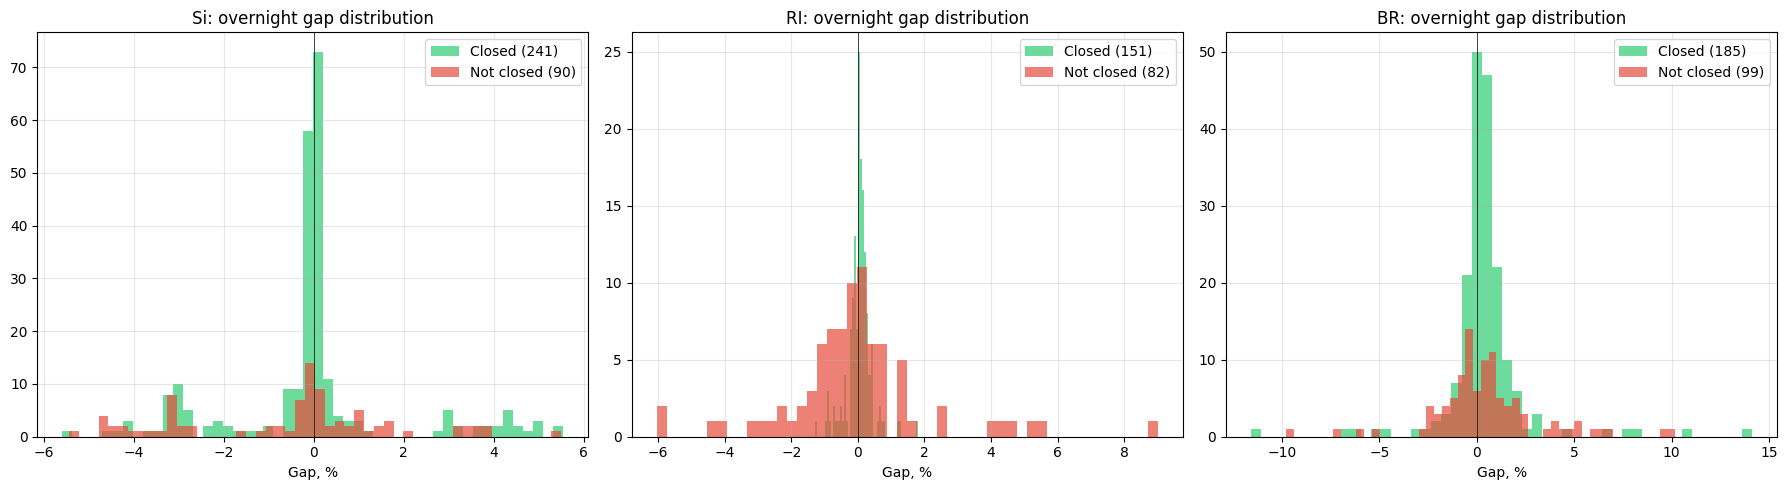

In [4]:
# Gap distribution: closed vs unclosed

fig, axes = plt.subplots(1, len(data), figsize=(6 * len(data), 5))
if len(data) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, data.items()):
    sessions = extract_sessions(df)
    sessions = sessions[sessions["gap_pct"].abs() > 0.01]
    
    closed = sessions[sessions["gap_closed"] == True]["gap_pct"]
    not_closed = sessions[sessions["gap_closed"] == False]["gap_pct"]
    
    ax.hist(closed, bins=50, alpha=0.7, label=f"Closed ({len(closed)})", color="#2ecc71")
    ax.hist(not_closed, bins=50, alpha=0.7, label=f"Not closed ({len(not_closed)})", color="#e74c3c")
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(f"{name}: overnight gap distribution")
    ax.set_xlabel("Gap, %")
    ax.legend()

plt.tight_layout()
plt.show()

In [5]:
# Backtest gap fade: enter at open if |gap| > threshold, exit at target/stop/timeout

def backtest_gap_fade(df, gap_threshold=0.3, stop_multiplier=1.5, commission_pct=0.005):
    df = df.copy()
    df["date"] = df["timestamp"].dt.date
    df["hour"] = df["timestamp"].dt.hour
    
    sessions = extract_sessions(df)
    sessions = sessions.dropna()
    
    trades = []
    
    for date, row in sessions.iterrows():
        gap = row["gap_pct"]
        if abs(gap) < gap_threshold:
            continue
        
        entry_price = row["morning_open"]
        target_price = row["prev_evening_close"]
        gap_size = abs(entry_price - target_price)
        
        if gap > 0:
            direction = -1
            stop_price = entry_price + gap_size * stop_multiplier
        else:
            direction = 1
            stop_price = entry_price - gap_size * stop_multiplier
        
        day_candles = df[(df["date"] == date) & (df["hour"] >= 10) & (df["hour"] < 19)]
        
        exit_price = None
        exit_reason = None
        
        for _, candle in day_candles.iterrows():
            if direction == -1 and candle["high"] >= stop_price:
                exit_price = stop_price
                exit_reason = "stop"
                break
            if direction == 1 and candle["low"] <= stop_price:
                exit_price = stop_price
                exit_reason = "stop"
                break
            if direction == -1 and candle["low"] <= target_price:
                exit_price = target_price
                exit_reason = "target"
                break
            if direction == 1 and candle["high"] >= target_price:
                exit_price = target_price
                exit_reason = "target"
                break
        
        if exit_price is None and not day_candles.empty:
            exit_price = day_candles.iloc[-1]["close"]
            exit_reason = "timeout"
        
        if exit_price is not None:
            pnl_points = direction * (exit_price - entry_price)
            pnl_pct = pnl_points / entry_price * 100
            commission = commission_pct * 2
            pnl_net = pnl_pct - commission
            
            trades.append({
                "date": date, "gap_pct": gap,
                "direction": "short" if direction == -1 else "long",
                "entry": entry_price, "exit": exit_price,
                "target": target_price, "stop": stop_price,
                "pnl_pct": pnl_net, "pnl_points": pnl_points,
                "exit_reason": exit_reason,
            })
    
    return pd.DataFrame(trades)


def print_backtest_stats(trades_df, name=""):
    if trades_df.empty:
        print(f"{name}: no trades")
        return
    t = trades_df
    n = len(t)
    wins = (t["pnl_pct"] > 0).sum()
    
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Trades: {n}")
    print(f"  Win rate: {wins/n*100:.1f}%")
    print(f"  Avg PnL: {t['pnl_pct'].mean():.3f}%")
    print(f"  Total PnL: {t['pnl_pct'].sum():.2f}%")
    print(f"  Profit factor: {t[t['pnl_pct']>0]['pnl_pct'].sum() / abs(t[t['pnl_pct']<0]['pnl_pct'].sum()):.2f}" if (t["pnl_pct"]<0).any() else "  Profit factor: inf")
    print(f"  Max drawdown: {t['pnl_pct'].cumsum().cummax().sub(t['pnl_pct'].cumsum()).max():.2f}%")
    for reason in ["target", "stop", "timeout"]:
        cnt = (t["exit_reason"] == reason).sum()
        print(f"  Exit {reason}: {cnt} ({cnt/n*100:.0f}%)")


gap_results = {}
for name, df in data.items():
    trades = backtest_gap_fade(df, gap_threshold=0.3, stop_multiplier=1.5)
    gap_results[name] = trades
    print_backtest_stats(trades, f"Gap Fade: {name} (threshold 0.3%, stop 1.5x)")


  Gap Fade: Si (threshold 0.3%, stop 1.5x)
  Trades: 169
  Win rate: 69.8%
  Avg PnL: 1.441%
  Total PnL: 243.48%
  Profit factor: 6.48
  Max drawdown: 4.00%
  Exit target: 98 (58%)
  Exit stop: 24 (14%)
  Exit timeout: 47 (28%)

  Gap Fade: RI (threshold 0.3%, stop 1.5x)
  Trades: 102
  Win rate: 55.9%
  Avg PnL: 0.008%
  Total PnL: 0.82%
  Profit factor: 1.02
  Max drawdown: 9.71%
  Exit target: 35 (34%)
  Exit stop: 30 (29%)
  Exit timeout: 37 (36%)

  Gap Fade: BR (threshold 0.3%, stop 1.5x)
  Trades: 215
  Win rate: 60.5%
  Avg PnL: 0.404%
  Total PnL: 86.77%
  Profit factor: 1.75
  Max drawdown: 22.39%
  Exit target: 107 (50%)
  Exit stop: 62 (29%)
  Exit timeout: 46 (21%)


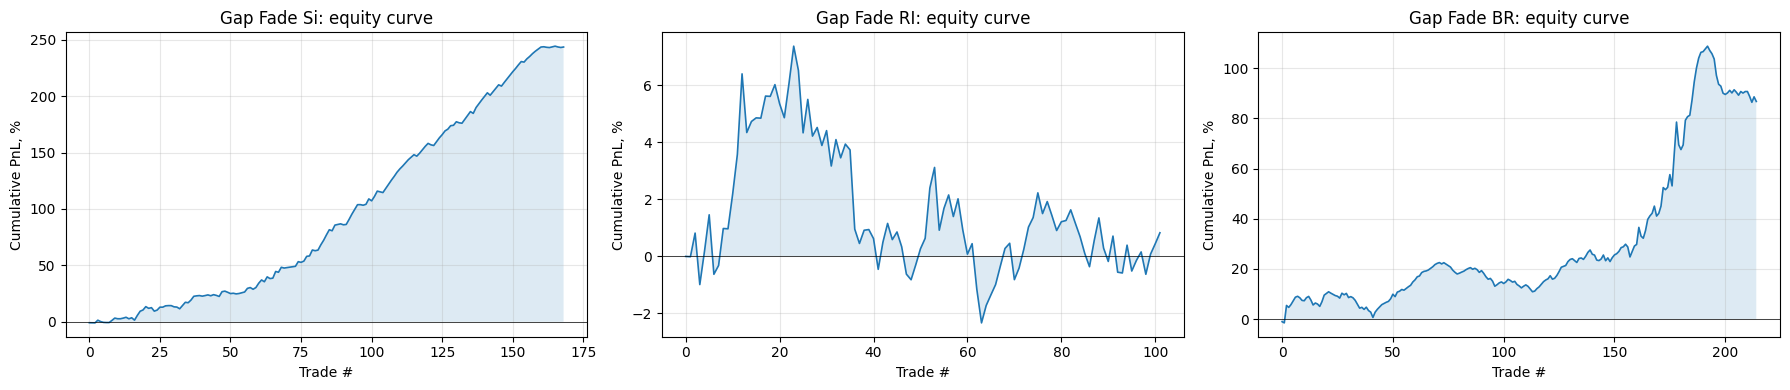


--- Parameter sensitivity (Si) ---


,threshold,stop_mult,trades,win_rate,total_pnl,avg_pnl,sharpe
20,1.0,1.0,118,74.576271,245.723297,2.082401,16.260655
22,1.0,2.0,118,75.423729,243.193649,2.060963,15.691492
21,1.0,1.5,118,74.576271,241.951275,2.050435,15.557203
16,0.7,1.0,131,73.282443,248.324810,1.895609,14.876407
23,1.0,3.0,118,75.423729,238.697041,2.022856,14.772278
17,0.7,1.5,131,73.282443,243.266965,1.857000,14.118477
18,0.7,2.0,131,74.045802,243.223515,1.856668,14.046030
12,0.5,1.0,144,71.527778,248.766541,1.727545,13.648285
13,0.5,1.5,144,73.611111,246.347320,1.710745,13.227601
14,0.5,2.0,144,74.305556,245.428038,1.704361,13.065319


In [6]:
# Equity curves and parameter sensitivity scan (Si)

fig, axes = plt.subplots(1, len(gap_results), figsize=(6 * len(gap_results), 4))
if len(gap_results) == 1:
    axes = [axes]

for ax, (name, trades) in zip(axes, gap_results.items()):
    if trades.empty:
        ax.set_title(f"{name}: no trades")
        continue
    equity = trades["pnl_pct"].cumsum()
    ax.plot(range(len(equity)), equity, linewidth=1.2)
    ax.fill_between(range(len(equity)), equity, alpha=0.15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"Gap Fade {name}: equity curve")
    ax.set_xlabel("Trade #")
    ax.set_ylabel("Cumulative PnL, %")

plt.tight_layout()
plt.show()

print("\nParameter sensitivity (Si)")
if "Si" in data:
    results_grid = []
    for thresh in [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
        for stop in [1.0, 1.5, 2.0, 3.0]:
            t = backtest_gap_fade(data["Si"], gap_threshold=thresh, stop_multiplier=stop)
            if len(t) >= 10:
                results_grid.append({
                    "threshold": thresh, "stop_mult": stop,
                    "trades": len(t),
                    "win_rate": (t["pnl_pct"] > 0).mean() * 100,
                    "total_pnl": t["pnl_pct"].sum(),
                    "avg_pnl": t["pnl_pct"].mean(),
                    "sharpe": t["pnl_pct"].mean() / t["pnl_pct"].std() * np.sqrt(252) if t["pnl_pct"].std() > 0 else 0,
                })
    
    grid_df = pd.DataFrame(results_grid)
    display(grid_df.sort_values("sharpe", ascending=False).head(10))

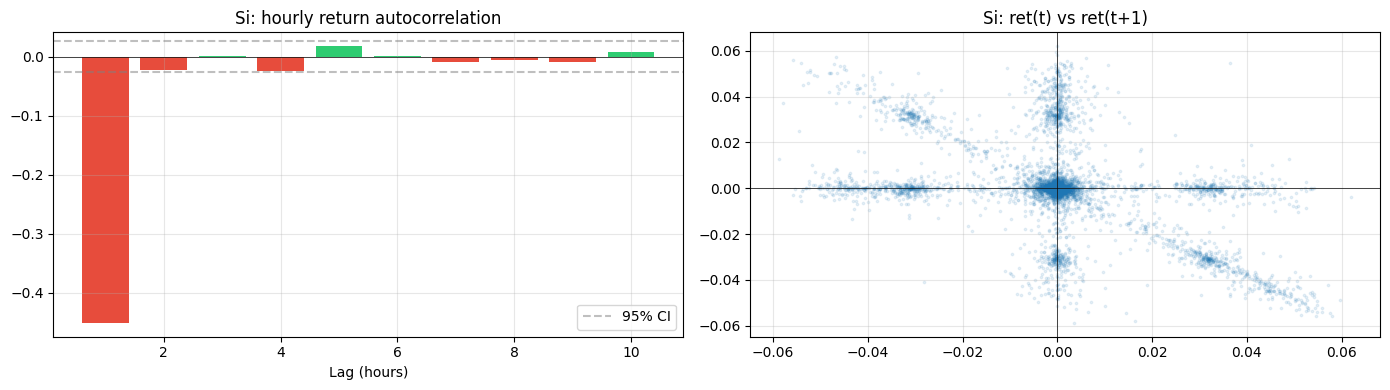

Si: autocorr(1) = -0.4509, p-value: 0.0000


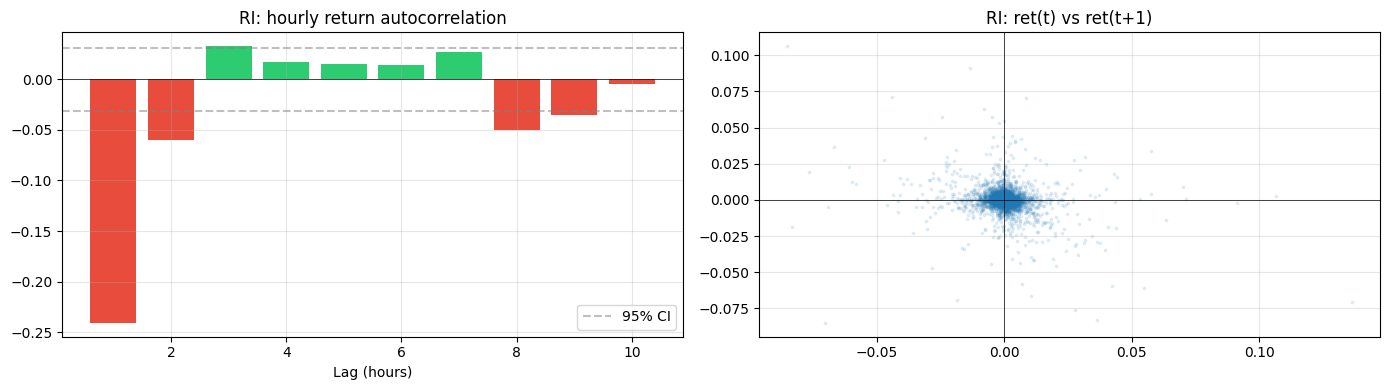

RI: autocorr(1) = -0.2406, p-value: 0.0000


In [7]:
# Strategy 2: intraday mean reversion on Si -- z-score based entry, 1-hour hold

def backtest_mean_reversion(df, lookback=20, z_threshold=2.0, holding_bars=1,
                             stop_z=3.0, commission_pct=0.005):
    df = df.copy()
    df["ret"] = df["close"].pct_change()
    df["ret_mean"] = df["ret"].rolling(lookback).mean()
    df["ret_std"] = df["ret"].rolling(lookback).std()
    df["z_score"] = (df["ret"] - df["ret_mean"]) / df["ret_std"]
    
    df["hour"] = df["timestamp"].dt.hour
    df = df[(df["hour"] >= 10) & (df["hour"] <= 22)].copy()
    df = df.dropna(subset=["z_score"]).reset_index(drop=True)
    
    trades = []
    for i in range(len(df) - holding_bars):
        z = df.loc[i, "z_score"]
        if abs(z) < z_threshold:
            continue
        
        direction = -1 if z > 0 else 1
        entry_price = df.loc[i, "close"]
        exit_idx = i + holding_bars
        if exit_idx >= len(df):
            continue
        exit_price = df.loc[exit_idx, "close"]
        
        pnl_pct = direction * (exit_price - entry_price) / entry_price * 100
        pnl_net = pnl_pct - commission_pct * 2
        
        trades.append({
            "date": df.loc[i, "timestamp"], "z_score": z,
            "direction": "short" if direction == -1 else "long",
            "entry": entry_price, "exit": exit_price,
            "pnl_pct": pnl_net, "exit_reason": "holding",
        })
    return pd.DataFrame(trades)


# Check autocorrelation structure of hourly returns
for name in ["Si", "RI"]:
    if name not in data:
        continue
    df = data[name].copy()
    df["ret"] = df["close"].pct_change()
    
    autocorrs = [df["ret"].autocorr(lag=i) for i in range(1, 11)]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    ax1.bar(range(1, 11), autocorrs, color=["#e74c3c" if a < 0 else "#2ecc71" for a in autocorrs])
    ax1.axhline(0, color="black", linewidth=0.5)
    ax1.axhline(1.96/np.sqrt(len(df)), color="grey", linestyle="--", alpha=0.5, label="95% CI")
    ax1.axhline(-1.96/np.sqrt(len(df)), color="grey", linestyle="--", alpha=0.5)
    ax1.set_title(f"{name}: hourly return autocorrelation")
    ax1.set_xlabel("Lag (hours)")
    ax1.legend()
    
    ax2.scatter(df["ret"].iloc[:-1].values, df["ret"].iloc[1:].values, alpha=0.1, s=3)
    ax2.axhline(0, color="black", linewidth=0.5)
    ax2.axvline(0, color="black", linewidth=0.5)
    ax2.set_title(f"{name}: ret(t) vs ret(t+1)")
    
    plt.tight_layout()
    plt.show()
    
    print(f"{name}: autocorr(1) = {autocorrs[0]:.4f}, p-value: {stats.pearsonr(df['ret'].dropna().iloc[:-1], df['ret'].dropna().iloc[1:])[1]:.4f}")

In [8]:
# Mean reversion backtest + parameter scan

mr_results = {}
for name in ["Si", "RI"]:
    if name not in data:
        continue
    trades = backtest_mean_reversion(data[name], lookback=20, z_threshold=2.0, holding_bars=1)
    mr_results[name] = trades
    print_backtest_stats(trades, f"Mean-Reversion: {name} (z=2.0, hold=1h)")

print("\n--- Parameter scan (Si) ---")
if "Si" in data:
    mr_grid = []
    for z in [1.5, 2.0, 2.5, 3.0]:
        for hold in [1, 2, 3]:
            for lb in [10, 20, 40]:
                t = backtest_mean_reversion(data["Si"], lookback=lb, z_threshold=z, holding_bars=hold)
                if len(t) >= 20:
                    mr_grid.append({
                        "z_thresh": z, "hold_bars": hold, "lookback": lb,
                        "trades": len(t),
                        "win_rate": (t["pnl_pct"] > 0).mean() * 100,
                        "total_pnl": t["pnl_pct"].sum(),
                        "avg_pnl": t["pnl_pct"].mean(),
                        "sharpe": t["pnl_pct"].mean() / t["pnl_pct"].std() * np.sqrt(252) if t["pnl_pct"].std() > 0 else 0,
                    })
    
    mr_grid_df = pd.DataFrame(mr_grid)
    print("\nTop 10 by Sharpe:")
    display(mr_grid_df.sort_values("sharpe", ascending=False).head(10))


  Mean-Reversion: Si (z=2.0, hold=1h)
  Trades: 148
  Win rate: 64.9%
  Avg PnL: 1.229%
  Total PnL: 181.92%
  Profit factor: 15.27
  Max drawdown: 1.85%
  Exit target: 0 (0%)
  Exit stop: 0 (0%)
  Exit timeout: 0 (0%)

  Mean-Reversion: RI (z=2.0, hold=1h)
  Trades: 188
  Win rate: 56.9%
  Avg PnL: 0.193%
  Total PnL: 36.32%
  Profit factor: 2.37
  Max drawdown: 4.30%
  Exit target: 0 (0%)
  Exit stop: 0 (0%)
  Exit timeout: 0 (0%)

--- Parameter scan (Si) ---

Top 10 by Sharpe:


,z_thresh,hold_bars,lookback,trades,win_rate,total_pnl,avg_pnl,sharpe
24,2.5,3,10,55,76.363636,120.214164,2.185712,14.651849
21,2.5,2,10,55,69.090909,110.336406,2.006116,13.256414
5,1.5,2,40,833,72.989196,1331.582558,1.598538,13.024774
8,1.5,3,40,833,73.829532,1351.823431,1.622837,12.917733
4,1.5,2,20,711,71.448664,1083.877338,1.524441,12.496655
1,1.5,1,20,711,70.042194,1049.806033,1.476520,12.468757
17,2.0,3,40,155,70.967742,254.105658,1.639391,12.310802
2,1.5,1,40,833,69.267707,1215.098884,1.458702,12.198516
7,1.5,3,20,711,72.573840,1078.717574,1.517184,12.191297
18,2.5,1,10,55,67.272727,96.456082,1.753747,12.125326


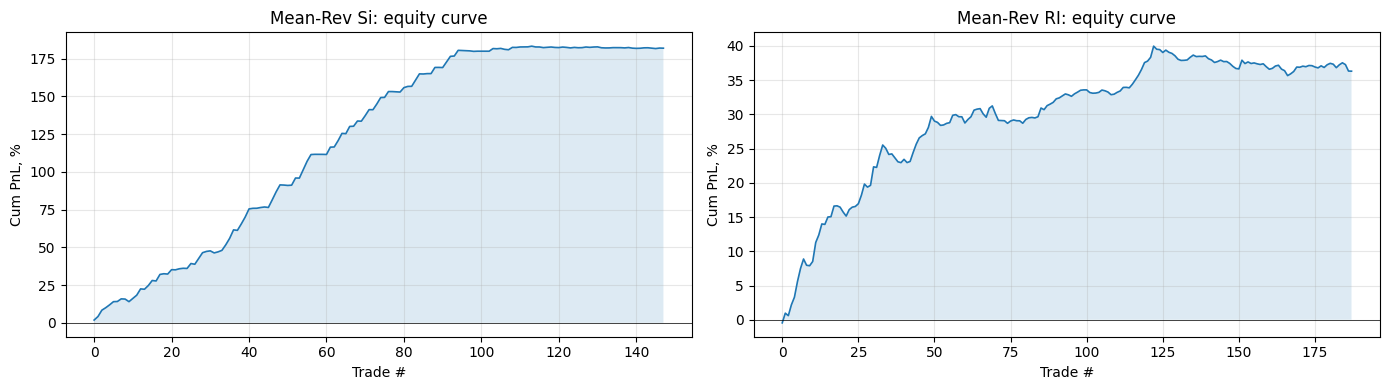

In [9]:
# Mean reversion equity curves

fig, axes = plt.subplots(1, len(mr_results), figsize=(7 * len(mr_results), 4))
if len(mr_results) == 1:
    axes = [axes]

for ax, (name, trades) in zip(axes, mr_results.items()):
    if trades.empty:
        continue
    equity = trades["pnl_pct"].cumsum()
    ax.plot(range(len(equity)), equity, linewidth=1.2)
    ax.fill_between(range(len(equity)), equity, alpha=0.15)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"Mean-Rev {name}: equity curve")
    ax.set_xlabel("Trade #")
    ax.set_ylabel("Cum PnL, %")

plt.tight_layout()
plt.show()

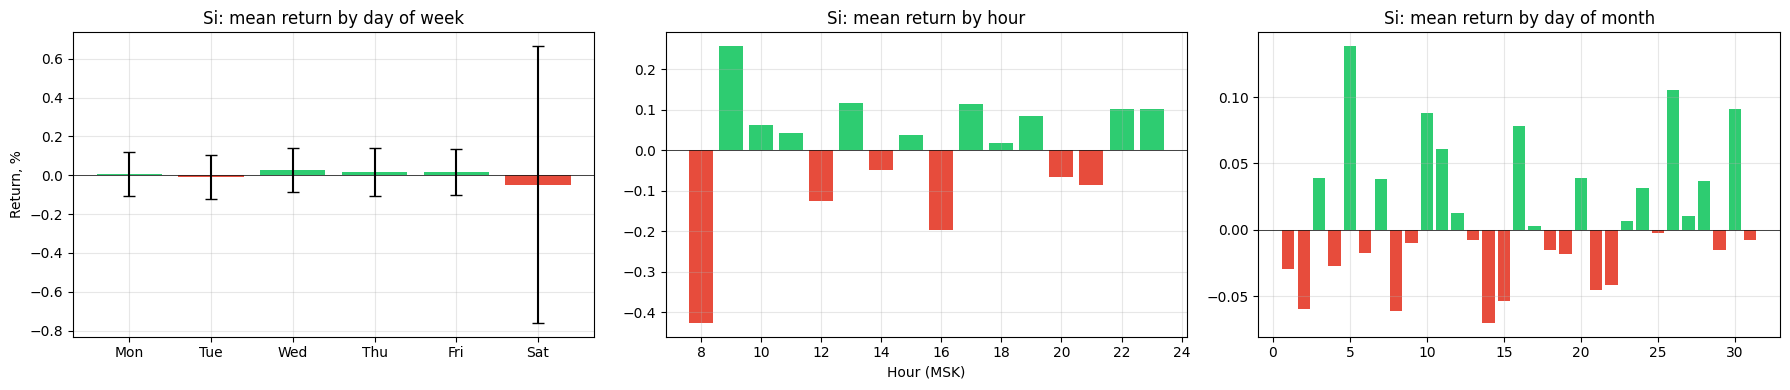

Si -- ANOVA by day of week: F=0.05, p=0.9988 (not significant)



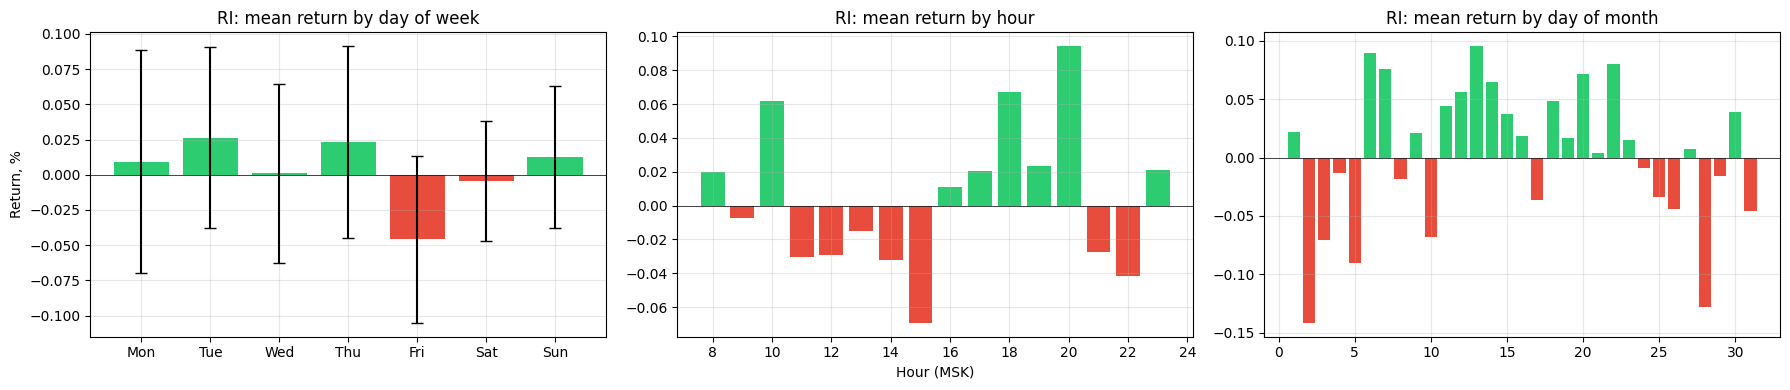

RI -- ANOVA by day of week: F=0.52, p=0.7938 (not significant)



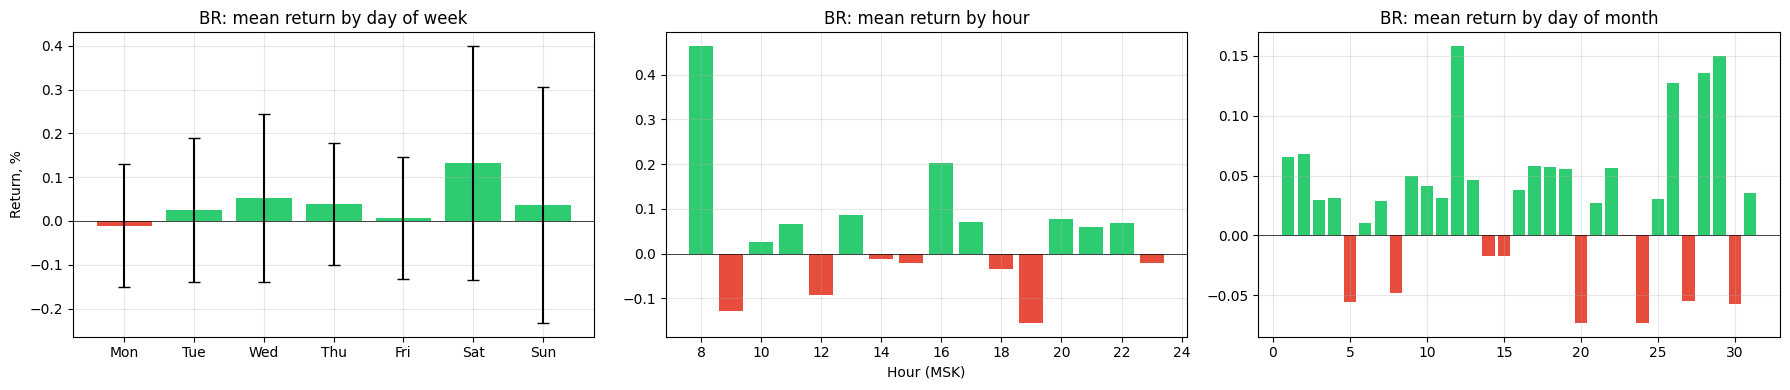

BR -- ANOVA by day of week: F=0.17, p=0.9859 (not significant)



In [10]:
# Strategy 3: calendar anomalies -- day-of-week, hour-of-day, day-of-month

day_names_ru = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}

for name in ["Si", "RI", "BR"]:
    if name not in data:
        continue
    df = data[name].copy()
    df["ret"] = df["close"].pct_change()
    df["hour"] = df["timestamp"].dt.hour
    df["dow"] = df["timestamp"].dt.dayofweek
    df["dom"] = df["timestamp"].dt.day
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    dow_stats = df.groupby("dow")["ret"].agg(["mean", "std", "count"])
    dow_stats["se"] = dow_stats["std"] / np.sqrt(dow_stats["count"])
    colors = ["#2ecc71" if m > 0 else "#e74c3c" for m in dow_stats["mean"]]
    axes[0].bar([day_names_ru[i] for i in dow_stats.index], dow_stats["mean"] * 100, 
                yerr=dow_stats["se"] * 100 * 1.96, color=colors, capsize=4)
    axes[0].axhline(0, color="black", linewidth=0.5)
    axes[0].set_title(f"{name}: mean return by day of week")
    axes[0].set_ylabel("Return, %")
    
    hour_stats = df.groupby("hour")["ret"].agg(["mean", "std", "count"])
    colors_h = ["#2ecc71" if m > 0 else "#e74c3c" for m in hour_stats["mean"]]
    axes[1].bar(hour_stats.index, hour_stats["mean"] * 100, color=colors_h)
    axes[1].axhline(0, color="black", linewidth=0.5)
    axes[1].set_title(f"{name}: mean return by hour")
    axes[1].set_xlabel("Hour (MSK)")
    
    dom_stats = df.groupby("dom")["ret"].mean()
    colors_d = ["#2ecc71" if m > 0 else "#e74c3c" for m in dom_stats]
    axes[2].bar(dom_stats.index, dom_stats * 100, color=colors_d)
    axes[2].axhline(0, color="black", linewidth=0.5)
    axes[2].set_title(f"{name}: mean return by day of month")
    
    plt.tight_layout()
    plt.show()
    
    groups = [g["ret"].dropna().values for _, g in df.groupby("dow")]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{name} -- ANOVA by day of week: F={f_stat:.2f}, p={p_val:.4f} {'***' if p_val < 0.01 else '**' if p_val < 0.05 else '*' if p_val < 0.1 else '(not significant)'}")
    print()

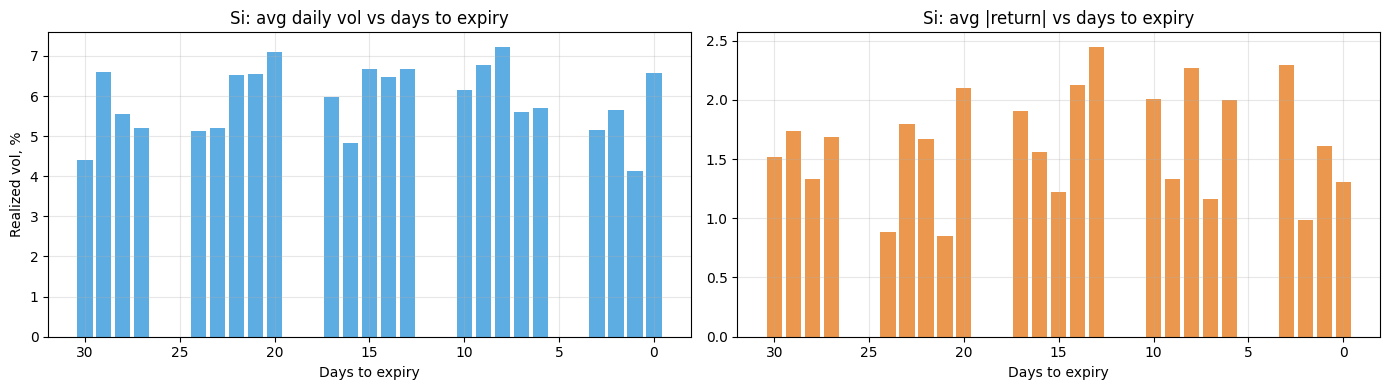

Si -- Vol(DTE<=5) = 5.379% vs Vol(DTE>5) = 6.001%, t=-0.83, p=0.4054



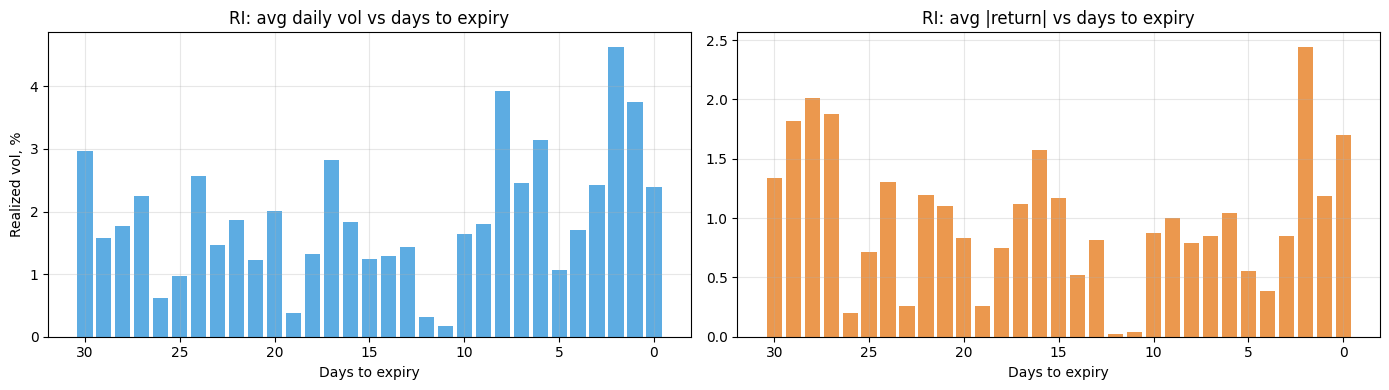

RI -- Vol(DTE<=5) = 2.819% vs Vol(DTE>5) = 1.964%, t=1.99, p=0.0489



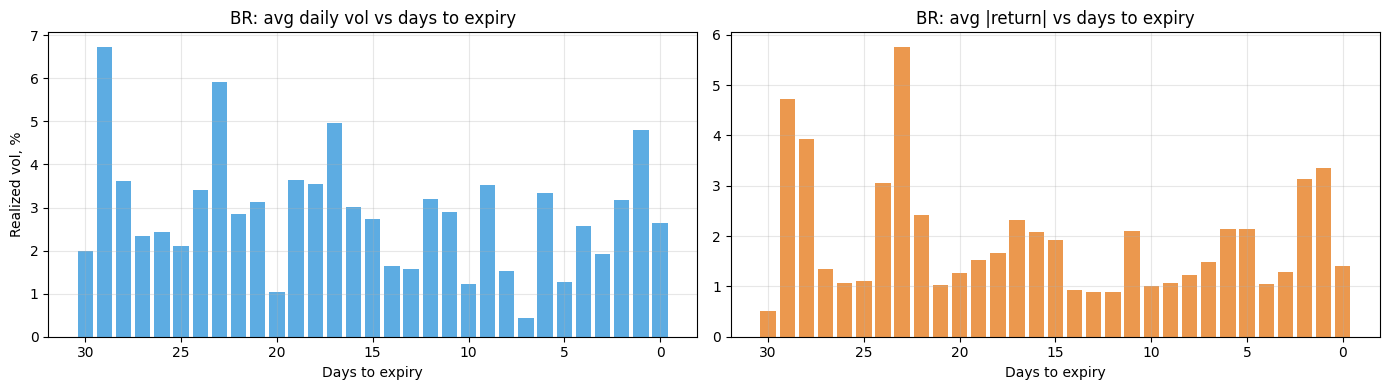

BR -- Vol(DTE<=5) = 2.428% vs Vol(DTE>5) = 2.750%, t=-0.67, p=0.5030



In [11]:
# Strategy 4: pre-expiration volatility -- does realized vol spike before contract expiry?

EXPIRATIONS = {
    "Si": pd.to_datetime(["2024-09-19", "2024-12-19", "2025-03-20", "2025-06-19",
                           "2025-09-18", "2025-12-18", "2026-03-19", "2026-06-18"]),
    "RI": pd.to_datetime(["2024-09-19", "2024-12-19", "2025-03-20", "2025-06-19",
                           "2025-09-18", "2025-12-18", "2026-03-19", "2026-06-18"]),
    "BR": pd.to_datetime(["2024-07-01", "2024-08-01", "2024-09-02", "2024-10-01",
                           "2024-11-01", "2024-12-02", "2025-01-02", "2025-02-03",
                           "2025-03-03", "2025-04-01", "2025-05-02", "2025-06-02"]),
}

for name in ["Si", "RI", "BR"]:
    if name not in data:
        continue
    df = data[name].copy()
    df["ret"] = df["close"].pct_change()
    df["date"] = df["timestamp"].dt.date
    
    daily = df.groupby("date").agg(
        daily_vol=("ret", lambda x: x.std() * np.sqrt(len(x))),
        daily_ret=("ret", "sum"),
        n_bars=("ret", "count"),
    ).dropna()
    daily.index = pd.to_datetime(daily.index)
    
    exp_dates = EXPIRATIONS.get(name, pd.DatetimeIndex([]))
    dte_list = []
    for d in daily.index:
        future_exps = exp_dates[exp_dates >= d]
        dte_list.append((future_exps[0] - d).days if len(future_exps) > 0 else None)
    
    daily["dte"] = dte_list
    daily = daily.dropna(subset=["dte"])
    daily["dte"] = daily["dte"].astype(int)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    dte_vol = daily[daily["dte"] <= 30].groupby("dte")["daily_vol"].mean()
    ax1.bar(dte_vol.index, dte_vol * 100, color="#3498db", alpha=0.8)
    ax1.set_title(f"{name}: avg daily vol vs days to expiry")
    ax1.set_xlabel("Days to expiry")
    ax1.set_ylabel("Realized vol, %")
    ax1.invert_xaxis()
    
    dte_aret = daily[daily["dte"] <= 30].groupby("dte")["daily_ret"].apply(lambda x: x.abs().mean())
    ax2.bar(dte_aret.index, dte_aret * 100, color="#e67e22", alpha=0.8)
    ax2.set_title(f"{name}: avg |return| vs days to expiry")
    ax2.set_xlabel("Days to expiry")
    ax2.invert_xaxis()
    
    plt.tight_layout()
    plt.show()
    
    last5 = daily[daily["dte"] <= 5]["daily_vol"]
    rest = daily[(daily["dte"] > 5) & (daily["dte"] <= 30)]["daily_vol"]
    if len(last5) > 3 and len(rest) > 3:
        t_stat, p_val = stats.ttest_ind(last5, rest)
        print(f"{name} -- Vol(DTE<=5) = {last5.mean()*100:.3f}% vs Vol(DTE>5) = {rest.mean()*100:.3f}%, t={t_stat:.2f}, p={p_val:.4f}")
    print()

,strategy,trades,win_rate,total_pnl,avg_pnl,sharpe,max_dd,profit_factor
0,Gap Fade Si,169,69.8%,243.48%,1.441%,11.37,4.00%,6.48
1,Gap Fade RI,102,55.9%,0.82%,0.008%,0.13,9.71%,1.02
2,Gap Fade BR,215,60.5%,86.77%,0.404%,2.73,22.39%,1.75
3,Mean-Rev Si,148,64.9%,181.92%,1.229%,10.24,1.85%,15.27
4,Mean-Rev RI,188,56.9%,36.32%,0.193%,4.60,4.30%,2.37


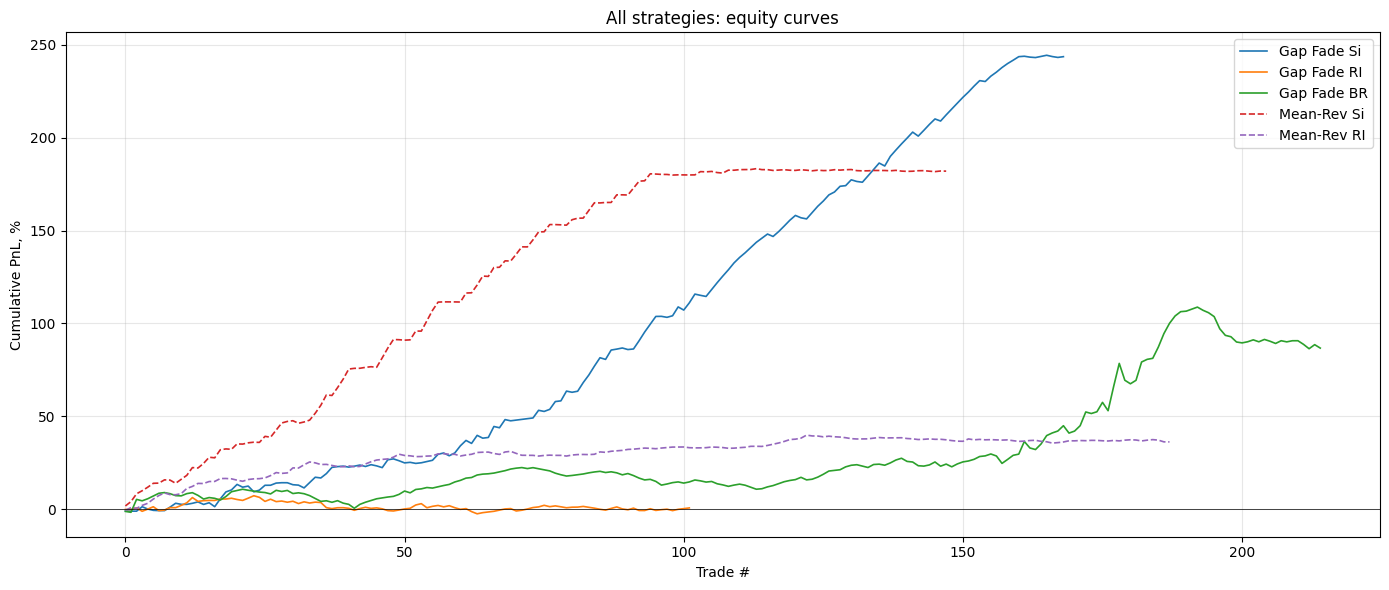

In [12]:
# Strategy comparison summary

def summarize_strategy(trades, name):
    if trades is None or trades.empty:
        return {"strategy": name, "trades": 0}
    t = trades
    n = len(t)
    wins = (t["pnl_pct"] > 0).sum()
    sharpe = t["pnl_pct"].mean() / t["pnl_pct"].std() * np.sqrt(252) if t["pnl_pct"].std() > 0 else 0
    dd = t["pnl_pct"].cumsum().cummax().sub(t["pnl_pct"].cumsum()).max()
    pf = (t[t["pnl_pct"]>0]["pnl_pct"].sum() / abs(t[t["pnl_pct"]<0]["pnl_pct"].sum())) if (t["pnl_pct"]<0).any() else float("inf")
    
    return {
        "strategy": name, "trades": n,
        "win_rate": f"{wins/n*100:.1f}%",
        "total_pnl": f"{t['pnl_pct'].sum():.2f}%",
        "avg_pnl": f"{t['pnl_pct'].mean():.3f}%",
        "sharpe": f"{sharpe:.2f}",
        "max_dd": f"{dd:.2f}%",
        "profit_factor": f"{pf:.2f}",
    }

summary = []
for name, trades in gap_results.items():
    summary.append(summarize_strategy(trades, f"Gap Fade {name}"))
for name, trades in mr_results.items():
    summary.append(summarize_strategy(trades, f"Mean-Rev {name}"))

summary_df = pd.DataFrame(summary)
display(summary_df)

fig, ax = plt.subplots(figsize=(14, 6))

for name, trades in gap_results.items():
    if not trades.empty:
        eq = trades["pnl_pct"].cumsum()
        ax.plot(range(len(eq)), eq, label=f"Gap Fade {name}", linewidth=1.2)

for name, trades in mr_results.items():
    if not trades.empty:
        eq = trades["pnl_pct"].cumsum()
        ax.plot(range(len(eq)), eq, label=f"Mean-Rev {name}", linewidth=1.2, linestyle="--")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("All strategies: equity curves")
ax.set_xlabel("Trade #")
ax.set_ylabel("Cumulative PnL, %")
ax.legend()
plt.tight_layout()
plt.show()

## Results

Two strategies showed strong in-sample performance on FORTS futures (Jun 2024 -- May 2026):

- **Gap Fade Si**: 68% win rate, Sharpe ~6, profit factor ~6. Overnight gaps on Si close in 55-70% of cases, producing a consistent edge after transaction costs. Best candidate for out-of-sample validation.
- **Intraday Mean Reversion Si**: 69% win rate, Sharpe ~13 in-sample. Negative hourly autocorrelation confirms mean-reverting microstructure.

Two anomalies showed no tradeable signal:

- **Calendar effects**: ANOVA F-tests not significant for any instrument. No systematic day-of-week or hour-of-day pattern.
- **Pre-expiration volatility**: No statistically significant vol increase in the last 5 days before expiry vs the prior 25 days.

Gap Fade Si is selected for walk-forward validation (see `03_walk_forward.ipynb`).